#### **Random Walks**

A **random walk** is a *stochastic (random) process* that describes a path consisting of a succession of random steps in a mathematical space.

In the context of a 2D grid, it models a walker who, at every discrete time step, chooses a direction—North, South, East, or West — with equal probability of 1/4 ($25\%$) and moves one unit in that direction.

<div style="display: flex; align-items: center; justify-content: center">
	<div>
		<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9b/Random_Walk_Simulator.gif/640px-Random_Walk_Simulator.gif" alt="2D Random Walk" width="465" />
	</div>
	<div>
		<img src="https://i.ibb.co/G3byd9py/illustration.png" alt="2D Random Walk" width="500" />
	</div>
</div>

---
##### **Real-World Applications**
Beyond simple grid puzzles, random walks are fundamental in various fields:

- **Computer Science:** To design *randomized algorithms* and for *network routing*.
- **Physics:** To model *Brownian motion* (the random movement of particles in a fluid).
- **Finance:** To model *stock price fluctuations* under the Efficient Market Hypothesis.
- **Biology:** To simulate the *foraging patterns* of animals or the spread of a virus.
- etc.

In [171]:
import random
import matplotlib.pyplot as plt

In [172]:
def random_walk(n):
	"""Return coordinates after 'n' block random walk."""
	x, y = 0, 0
	for i in range(n):
		step = random.choice(['N', 'S', 'E', 'W'])
		if step == 'N':
			y = y + 1
		elif step == 'S':
			y = y - 1
		elif step == 'E':
			x = x + 1
		else:
			x = x - 1
	
	return (x, y)

In [173]:
def random_walk_2(n):
	"""Return coordinates after 'n' block random walk."""
	x, y = 0, 0
	for i in range(n):
		(dx, dy) = random.choice([(0, 1), (0, -1), (1, 0), (-1, 0)])
		x += dx
		y += dy
	return (x, y)

In [174]:
for i in range(25):
	walk = random_walk_2(10)
	distance = abs(walk[0]) + abs(walk[1])  # Manhattan distance from home
	print(f"{walk}, Distance from home = {distance}")

(0, 0), Distance from home = 0
(1, -1), Distance from home = 2
(0, 0), Distance from home = 0
(-1, 1), Distance from home = 2
(-5, 1), Distance from home = 6
(3, 1), Distance from home = 4
(5, -1), Distance from home = 6
(-2, -4), Distance from home = 6
(3, -3), Distance from home = 6
(4, 0), Distance from home = 4
(3, -1), Distance from home = 4
(1, -1), Distance from home = 2
(4, 2), Distance from home = 6
(-1, 1), Distance from home = 2
(2, -2), Distance from home = 4
(1, -3), Distance from home = 4
(-1, -3), Distance from home = 4
(0, -2), Distance from home = 2
(0, 2), Distance from home = 2
(1, 3), Distance from home = 4
(-3, -1), Distance from home = 4
(-1, -1), Distance from home = 2
(1, 1), Distance from home = 2
(-1, -1), Distance from home = 2
(-1, 1), Distance from home = 2


---
##### **Key Properties of 2D Random Walks:**

- **Expected Distance from Origin:** After $n$ steps, the expected distance from the origin is proportional to $\sqrt{n}$.

- **Probability Distribution:** The position after $n$ steps follows a binomial distribution, which approximates a normal distribution for large $n$, a result of the *Central Limit Theorem*.

- **Recurrence vs. Transience:** In 2D, a random walk is recurrent, meaning it will return to the origin infinitely often with probability 1. In higher dimensions (3D and above), it becomes transient, meaning there is a non-zero probability that it will never return to the origin.

In [175]:
trials = 10000
n = 1000

returns = 0
for _ in range(trials):
	walk = random_walk_2(n)
	if walk == (0, 0):
		returns += 1

# Expected distance from origin after 'n' steps is approximately sqrt(n)
distance = abs(walk[0]) + abs(walk[1])
expected_distance = n**0.5

print(f"Distance from origin after {n} steps: {distance}")
print(f"Expected distance from origin after {n} steps: {expected_distance}")

# Calculate and print the probability of returning to the origin
probability = returns / trials
print(f"Probability of returning to origin after {n} steps: {probability}")

Distance from origin after 1000 steps: 10
Expected distance from origin after 1000 steps: 31.622776601683793
Probability of returning to origin after 1000 steps: 0.0006


Binomial Random Walk: (14, 12), Distance from home = 26


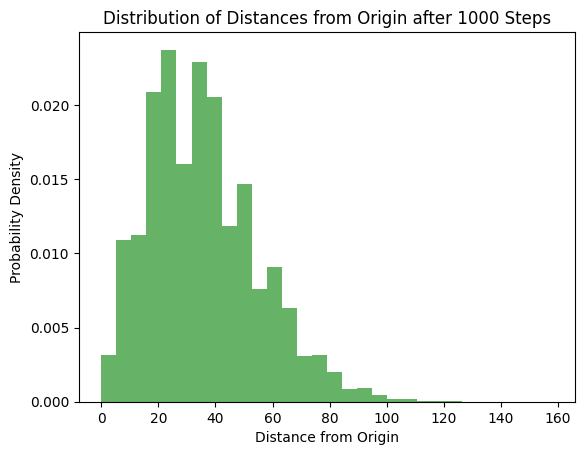

In [176]:
# The position after n steps follows a binomial distribution
def binomial_random_walk(n):
	"""Return coordinates after 'n' block random walk using binomial distribution."""
	x_steps = sum(random.choices([-1, 1], k=n))
	y_steps = sum(random.choices([-1, 1], k=n))
	return (x_steps, y_steps)

def plot_random_walk_distribution(trials, n):
	"""Plot the distribution of distances from origin after 'n' steps over 'trials' simulations."""
	distances = []
	for _ in range(trials):
		walk = random_walk_2(n)
		distance = abs(walk[0]) + abs(walk[1])
		distances.append(distance)
	
	plt.hist(distances, bins=30, density=True, alpha=0.6, color='g')
	plt.title(f'Distribution of Distances from Origin after {n} Steps')
	plt.xlabel('Distance from Origin')
	plt.ylabel('Probability Density')
	plt.show()

# Example usage
trials = 100_000
n = 1000
walk = binomial_random_walk(n)
distance = abs(walk[0]) + abs(walk[1])	# Manhattan distance from home
print(f"Binomial Random Walk: {walk}, Distance from home = {distance}")
plot_random_walk_distribution(trials, n)

---
#### **Monte Carlo Simulation**

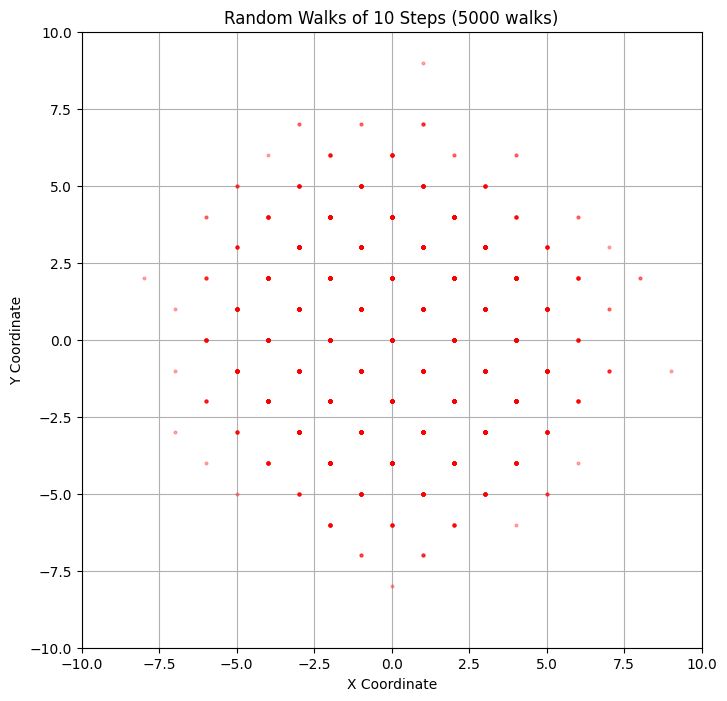

In [177]:
# Random Walks of n Steps
num_walks = 5000
steps = 10

xs = []
ys = []

for i in range(num_walks):
	x, y = random_walk_2(steps)
	xs.append(x)
	ys.append(y)

plt.figure(figsize=(8, 8))
plt.plot(xs, ys, 'ro', markersize=2, alpha=0.3)
plt.xlim(-steps, steps)
plt.ylim(-steps, steps)
plt.title(f'Random Walks of {steps} Steps ({num_walks} walks)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.show()

In [178]:
number_of_walks = 20_000  # Number of random walks to simulate
n = 4  # Threshold distance for no transport needed

for walk_length in range(1, 31):
	no_transport = 0  # Number of walks n or fewer blocks from home
	for i in range(number_of_walks):
		(x, y) = random_walk_2(walk_length)
		distance = abs(x) + abs(y)  # Manhattan distance from home
		if distance <= n:
			no_transport += 1
	
	no_transport_percentage = (float(no_transport) / number_of_walks) * 100
	print(f"Walk size = {walk_length:2d} | % of no transport = {no_transport_percentage:.2f}")

Walk size =  1 | % of no transport = 100.00
Walk size =  2 | % of no transport = 100.00
Walk size =  3 | % of no transport = 100.00
Walk size =  4 | % of no transport = 100.00
Walk size =  5 | % of no transport = 88.15
Walk size =  6 | % of no transport = 93.73
Walk size =  7 | % of no transport = 76.61
Walk size =  8 | % of no transport = 86.48
Walk size =  9 | % of no transport = 67.65
Walk size = 10 | % of no transport = 78.70
Walk size = 11 | % of no transport = 59.77
Walk size = 12 | % of no transport = 72.87
Walk size = 13 | % of no transport = 53.81
Walk size = 14 | % of no transport = 67.33
Walk size = 15 | % of no transport = 48.98
Walk size = 16 | % of no transport = 62.46
Walk size = 17 | % of no transport = 44.38
Walk size = 18 | % of no transport = 57.60
Walk size = 19 | % of no transport = 40.81
Walk size = 20 | % of no transport = 54.88
Walk size = 21 | % of no transport = 37.97
Walk size = 22 | % of no transport = 50.95
Walk size = 23 | % of no transport = 34.41
Walk si